In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [18]:
# ============================================================
# WeatherTrendAI
# Forecasting Notebook
# ============================================================

import warnings
warnings.filterwarnings("ignore")

# ==========================
# Data Handling
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Visualization
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# ==========================
# Machine Learning
# ==========================
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    IsolationForest,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

# ==========================
# XGBoost & LightGBM
# ==========================
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ==========================
# Time Series
# ==========================
from prophet import Prophet

# ==========================
# Model Explainability
# ==========================
import shap

# ==========================
# Utilities
# ==========================
import os
from pathlib import Path

# ============================================================
# Load Dataset
# ============================================================

DATA_PATH = "../data/raw/weather.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "../data/raw/weather.csv"

df = pd.read_csv(DATA_PATH)

# ============================================================
# Datetime Processing
# ============================================================

df["last_updated"] = pd.to_datetime(df["last_updated"])

df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day
df["hour"] = df["last_updated"].dt.hour

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print("="*60)

df.head()

Dataset Loaded Successfully
Rows    : 151047
Columns : 45


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,day,hour
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024,5,16,13
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55,2024,5,16,10
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55,2024,5,16,9
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55,2024,5,16,10
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024,5,16,9


In [19]:
features = [
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "cloud",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

X = df[features]

y = df["temperature_celsius"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120837, 9)
(30210, 9)


In [21]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [22]:
def evaluate(name, y_true, pred):

    mae = mean_absolute_error(y_true, pred)

    rmse = np.sqrt(mean_squared_error(y_true, pred))

    r2 = r2_score(y_true, pred)

    print(name)
    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R2  :", round(r2,4))
    print("-"*40)

In [23]:
evaluate(
    "Linear Regression",
    y_test,
    lr_pred
)

Linear Regression
MAE : 6.02
RMSE: 8.28
R2  : 0.2491
----------------------------------------


In [24]:
df = df.sample(
    n=30000,
    random_state=42
).reset_index(drop=True)

In [25]:
features = [
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "cloud",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

X = df[features]
y = df["temperature_celsius"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (24000, 9)
Test : (6000, 9)


In [27]:

# Random Forest Regressor


rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

evaluate(
    "Random Forest",
    y_test,
    rf_pred
)

Random Forest
MAE : 4.01
RMSE: 5.59
R2  : 0.6604
----------------------------------------


In [28]:

# XGBoost Regressor


xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=1
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

evaluate(
    "XGBoost",
    y_test,
    xgb_pred
)

XGBoost
MAE : 3.85
RMSE: 5.34
R2  : 0.6898
----------------------------------------


In [29]:

# LightGBM Regressor


lgb = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)

evaluate(
    "LightGBM",
    y_test,
    lgb_pred
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1381
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 9
[LightGBM] [Info] Start training from score 21.242100
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [30]:
# ==========================================================
# Prepare Time Series Dataset for Prophet
# ==========================================================

import pandas as pd

# Aggregate average temperature by timestamp
ts_df = (
    df.groupby("last_updated")["temperature_celsius"]
      .mean()
      .reset_index()
)

# Prophet requires columns named ds and y
ts_df = ts_df.rename(
    columns={
        "last_updated": "ds",
        "temperature_celsius": "y"
    }
)

print(ts_df.head())
print(f"\nTotal observations: {len(ts_df)}")

                   ds          y
0 2024-05-16 01:45:00  16.100000
1 2024-05-16 02:45:00  24.000000
2 2024-05-16 04:45:00  15.600000
3 2024-05-16 08:45:00  16.833333
4 2024-05-16 09:45:00  30.300000

Total observations: 13153


In [31]:
# ==========================================================
# Prophet Forecasting
# ==========================================================

from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

model.fit(ts_df)

17:42:04 - cmdstanpy - INFO - Chain [1] start processing
17:42:05 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
# ==========================================================
# Forecast Future Weather Trend
# ==========================================================

future = model.make_future_dataframe(
    periods=30,
    freq="h"      # lowercase h
)

forecast = model.predict(future)

forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].tail()

,ds,yhat,yhat_lower,yhat_upper
13178,2026-07-04 21:00:00,27.421725,18.504317,37.025907
13179,2026-07-04 22:00:00,26.323800,16.688144,35.524984
13180,2026-07-04 23:00:00,24.798532,15.565755,33.680137
13181,2026-07-05 00:00:00,23.376124,14.082558,32.741398
13182,2026-07-05 01:00:00,22.619466,13.162980,31.668668


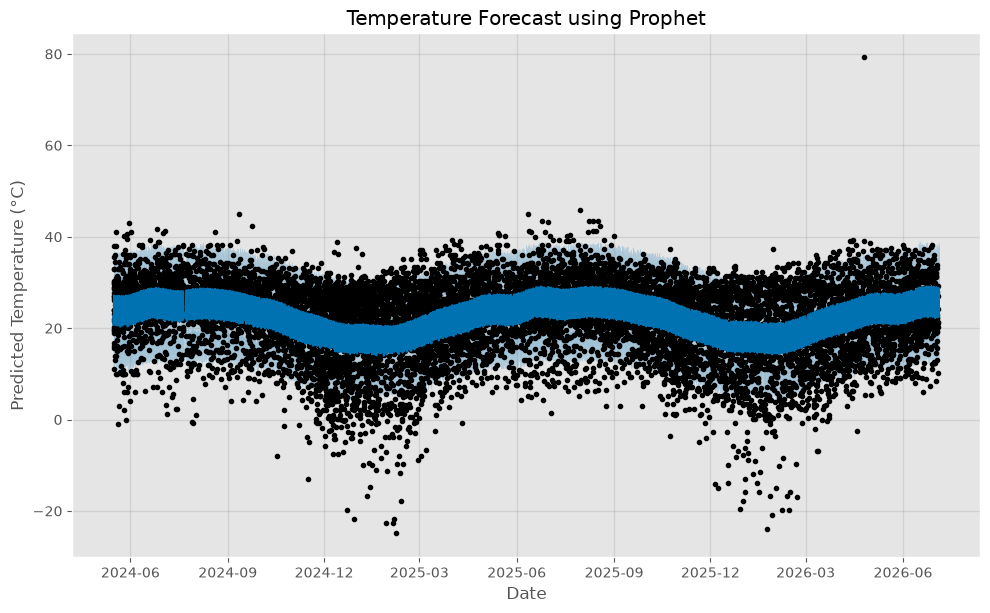

In [34]:
# ==========================================================
# Forecast Visualization
# ==========================================================

fig = model.plot(forecast)

plt.title("Temperature Forecast using Prophet")
plt.xlabel("Date")
plt.ylabel("Predicted Temperature (°C)")

plt.show()

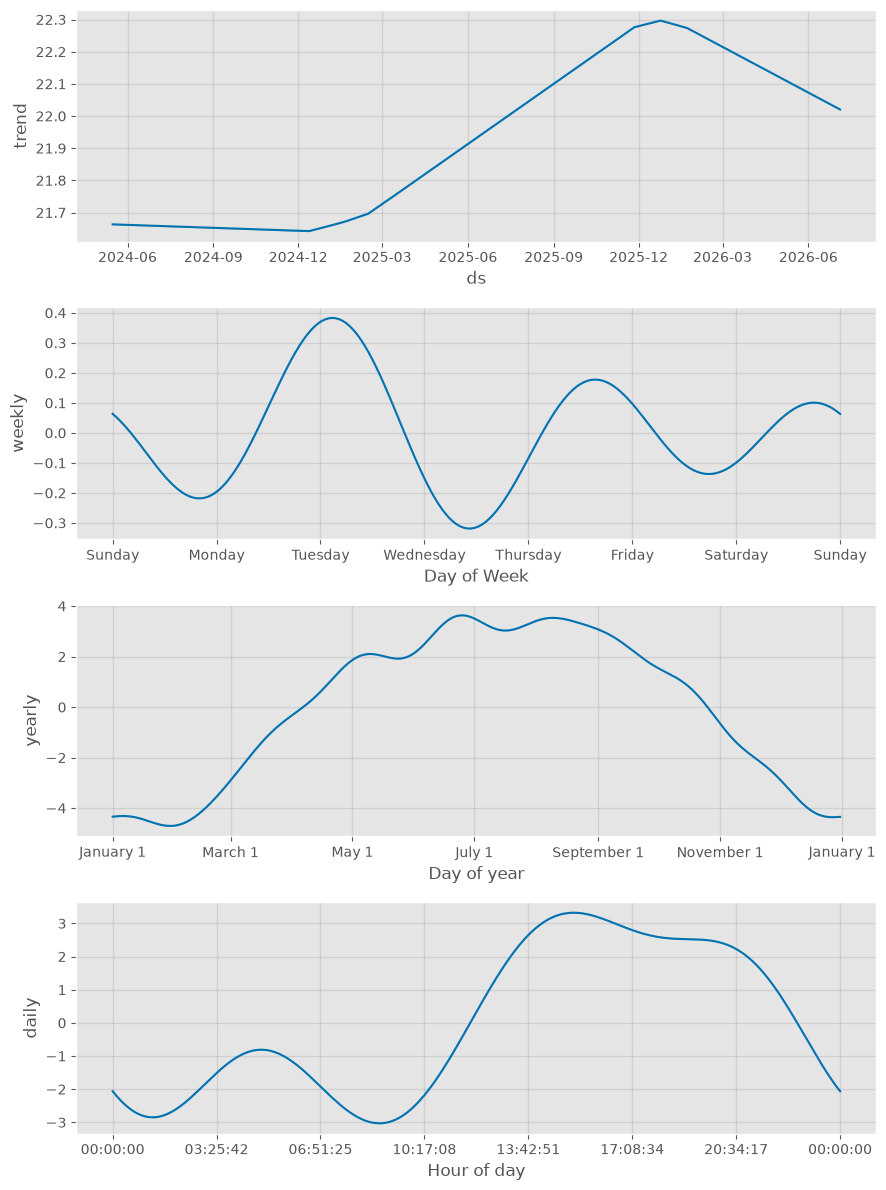

In [37]:
# ==========================================================
# Trend Components
# ==========================================================

model.plot_components(forecast)

plt.show()

In [36]:
# ==========================================================
# Save Forecast
# ==========================================================

forecast.to_csv(
    "../outputs/predictions/prophet_forecast.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.
